# K-Means on PCA-Reduced Data (2 Components)

This notebook runs K-Means (k=2) on X_pca_2.csv and logs metrics to clustering_summary.csv.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import mode
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

In [2]:
N_COMPONENTS = 2

project_root = Path.cwd()
if not (project_root / 'data' / 'processed').exists() and (project_root.parent / 'data' / 'processed').exists():
    project_root = project_root.parent

processed_dir = project_root / 'data' / 'processed'
summary_path = project_root / 'results' / 'metrics' / 'clustering_summary.csv'

X = pd.read_csv(processed_dir / f'X_pca_{N_COMPONENTS}.csv')
y = pd.read_csv(processed_dir / 'y_sample.csv').squeeze()

print(f'Loaded X shape: {X.shape}')
print(f'Loaded y shape: {y.shape}')

Loaded X shape: (200000, 2)
Loaded y shape: (200000,)


In [3]:
train_start = time.time()
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=20)
kmeans.fit(X)
training_time = time.time() - train_start

pred_start = time.time()
y_pred = kmeans.predict(X)
prediction_time = time.time() - pred_start

mapped_labels = np.zeros_like(y_pred)
for cluster_id in range(2):
    mask = y_pred == cluster_id
    mapped_labels[mask] = mode(y[mask], keepdims=True).mode[0]

accuracy = accuracy_score(y, mapped_labels) * 100

print(f'Training time: {training_time:.4f} sec')
print(f'Prediction time: {prediction_time:.4f} sec')
print(f'Iterations: {kmeans.n_iter_}')
print(f'Accuracy (mapped clusters): {accuracy:.4f}%')

Training time: 7.3830 sec
Prediction time: 0.1728 sec
Iterations: 13
Accuracy (mapped clusters): 54.7165%


In [4]:
new_row = pd.DataFrame([{
    'method': f'KMeans PCA {N_COMPONENTS}',
    'dataset_version': 'sample_200k',
    'n_clusters': 2,
    'n_rows': X.shape[0],
    'n_features': X.shape[1],
    'training_time_seconds': training_time,
    'prediction_time_seconds': prediction_time,
    'iterations': kmeans.n_iter_,
    'accuracy': accuracy,
    'silhouette_score': None,
    'davies_bouldin': None,
    'compactness': None,
    'separation': None
}])

if summary_path.exists():
    df_summary = pd.read_csv(summary_path)
    df_summary = df_summary[~((df_summary['method'] == f'KMeans PCA {N_COMPONENTS}') & (df_summary['dataset_version'] == 'sample_200k'))]
    df_summary = pd.concat([df_summary, new_row], ignore_index=True)
else:
    df_summary = new_row

df_summary.to_csv(summary_path, index=False)
print(df_summary.tail().to_string(index=False))

        method    dataset_version  n_clusters   n_rows  n_features  training_time_seconds  prediction_time_seconds  iterations  accuracy  silhouette_score  davies_bouldin  compactness  separation       quality_metrics_status
  KMeans PCA 5        sample_200k           2   200000           5               5.958061                 0.018394          14  55.67800          0.349828        1.470113     8.180057    2.417803 evaluated_sampled_silhouette
 KMeans PCA 10        sample_200k           2   200000          10               7.992132                 0.025261           6  55.63800          0.265126        1.981374    14.306274    2.422995 evaluated_sampled_silhouette
KMeans Full 28 HIGGS.csv.gz(full)           2 10721302          28              16.070961                 2.503036          18  55.68153               NaN             NaN          NaN         NaN                          NaN
KMeans Full 28        sample_200k           2   200000          28               2.448016           

C:\Users\austi\AppData\Local\Temp\ipykernel_9324\1507903300.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_summary = pd.concat([df_summary, new_row], ignore_index=True)


## Graphical Analysis

This section creates comparison charts from `clustering_summary.csv` and a PCA-2 cluster visualization.


1. **Runtime Comparison (Full vs PCA)**
   - PCA variants have very small prediction times and moderate training times.
   - The full 28-feature sampled run is fastest to train in this snapshot, while PCA-10 is the slowest among PCA variants.
   - This indicates dimensionality reduction did not guarantee faster fitting for this specific data/initialization path.

2. **PCA-2 Cluster Scatter Plot**
   - The two cluster colors overlap heavily in the center region, with separation mostly along PC1.
   - This visual overlap matches the moderate accuracy values and suggests limited natural separation between classes for K-Means.

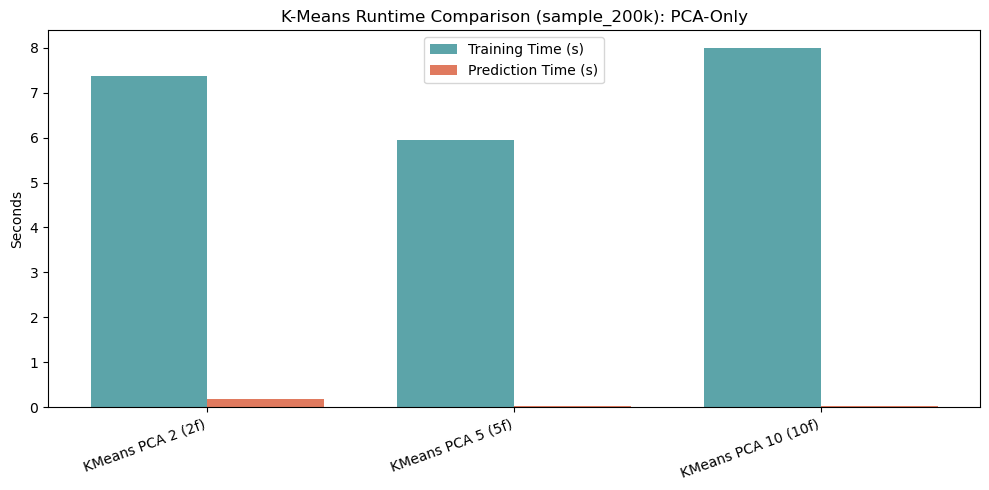

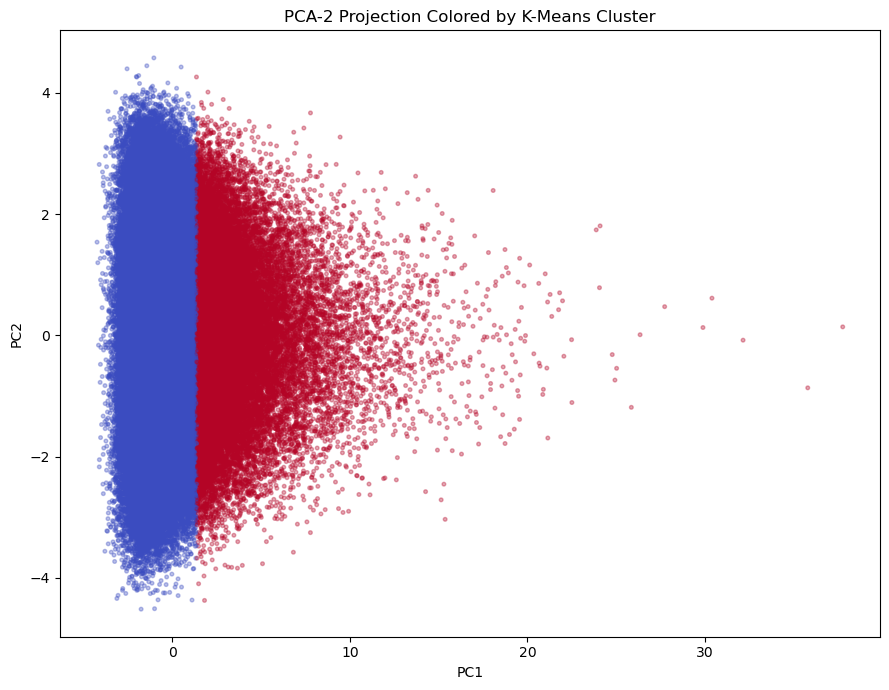

In [5]:
import matplotlib.pyplot as plt

viz_dir = project_root / 'results' / 'visualizations'
viz_dir.mkdir(parents=True, exist_ok=True)

df_metrics = pd.read_csv(summary_path)
plot_methods = ['KMeans PCA 2', 'KMeans PCA 5', 'KMeans PCA 10']

# Runtime comparison for PCA-only runs on the same sampled dataset.
plot_df = df_metrics[
    (df_metrics['method'].isin(plot_methods)) &
    (df_metrics['dataset_version'] == 'sample_200k')
].copy()
plot_df = plot_df.drop_duplicates(subset=['method', 'dataset_version'], keep='last')
plot_df = plot_df.sort_values('n_features')

labels = [f"{m} ({f}f)" for m, f in zip(plot_df['method'], plot_df['n_features'])]

# Runtime comparison chart (training and prediction)
plt.figure(figsize=(10, 5))
bar_w = 0.38
x = np.arange(len(plot_df))
plt.bar(x - bar_w / 2, plot_df['training_time_seconds'], width=bar_w, label='Training Time (s)', color='#5ca4a9')
plt.bar(x + bar_w / 2, plot_df['prediction_time_seconds'], width=bar_w, label='Prediction Time (s)', color='#e07a5f')
plt.xticks(x, labels, rotation=20, ha='right')
plt.ylabel('Seconds')
plt.title('K-Means Runtime Comparison (sample_200k): PCA-Only')
plt.legend()
plt.tight_layout()
plt.savefig(viz_dir / 'kmeans_runtime_comparison.png', dpi=150)
plt.show()

# PCA-2 scatter plot colored by assigned cluster
plt.figure(figsize=(9, 7))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_pred, cmap='coolwarm', alpha=0.35, s=7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA-2 Projection Colored by K-Means Cluster')
plt.tight_layout()
plt.savefig(viz_dir / 'kmeans_pca2_cluster_scatter.png', dpi=150)
plt.show()

## Combined Cluster Scatter (PCA-2, PCA-5, PCA-10)

This single figure compares K-Means cluster assignments across all three PCA-reduced datasets using PC1 vs PC2 for each setting.

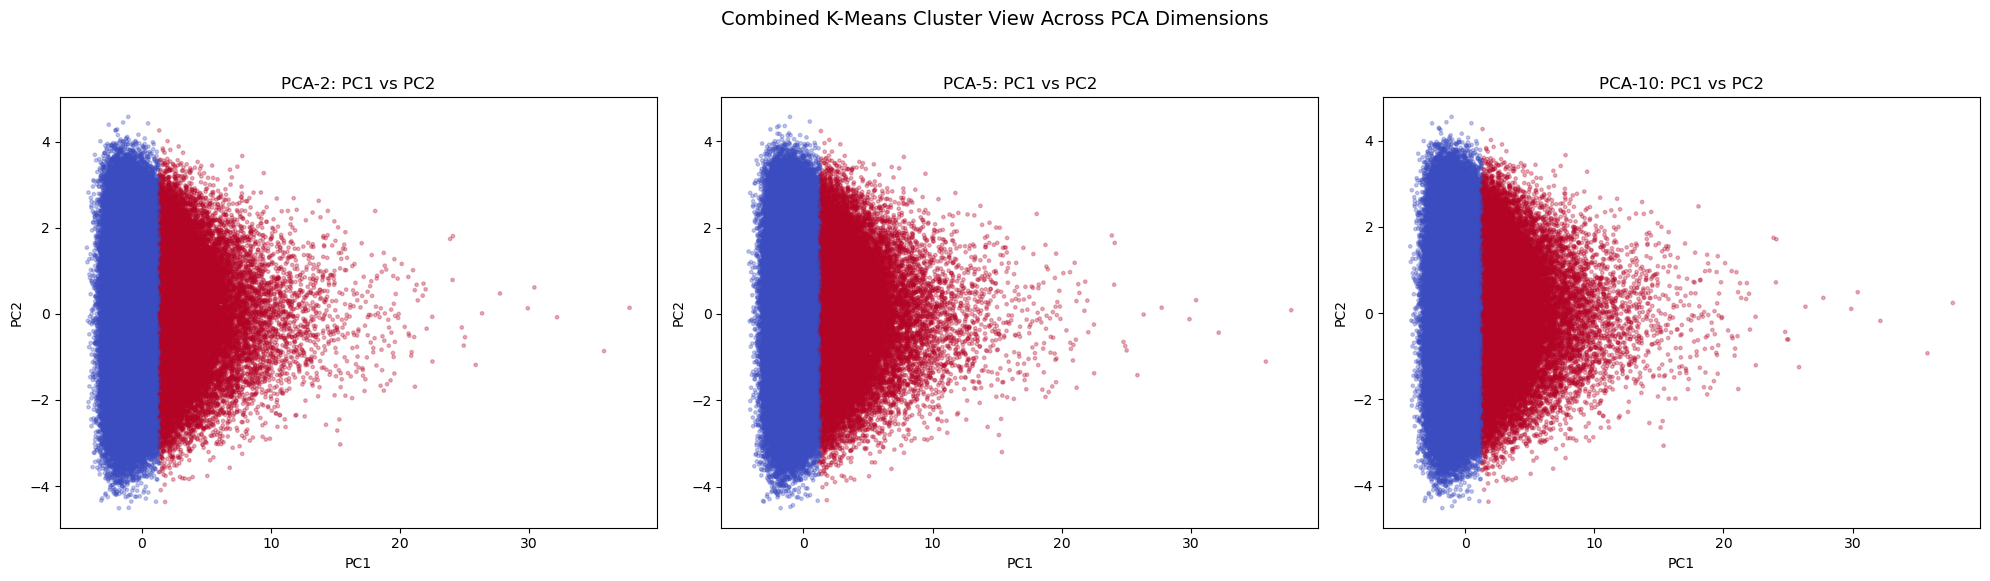

Saved visualization: results/visualizations/kmeans_pca_combined_scatter.png


In [6]:
import matplotlib.pyplot as plt

viz_dir = project_root / 'results' / 'visualizations'
viz_dir.mkdir(parents=True, exist_ok=True)

component_list = [2, 5, 10]
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=False, sharey=False)

for ax, n_comp in zip(axes, component_list):
    X_plot = pd.read_csv(processed_dir / f'X_pca_{n_comp}.csv')

    km = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=20)
    cluster_labels = km.fit_predict(X_plot)

    ax.scatter(X_plot.iloc[:, 0], X_plot.iloc[:, 1], c=cluster_labels, cmap='coolwarm', alpha=0.30, s=6)
    ax.set_title(f'PCA-{n_comp}: PC1 vs PC2')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

fig.suptitle('Combined K-Means Cluster View Across PCA Dimensions', fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])
fig.savefig(viz_dir / 'kmeans_pca_combined_scatter.png', dpi=150)
plt.show()

print('Saved visualization: results/visualizations/kmeans_pca_combined_scatter.png')

### Explanation

- **What each panel shows:** The three panels correspond to PCA-2, PCA-5, and PCA-10. In each panel, points are plotted on PC1 vs PC2 and colored by K-Means cluster assignment.
- **How to read it:** If clusters were clearly separable, you would see distinct, minimally overlapping color regions. Instead, all panels show substantial overlap.
- **Key takeaway:** The visual structure is broadly similar across PCA dimensions, which supports the near-identical accuracies (around 55.6% to 55.7%) and indicates limited class separability for K-Means on this dataset.